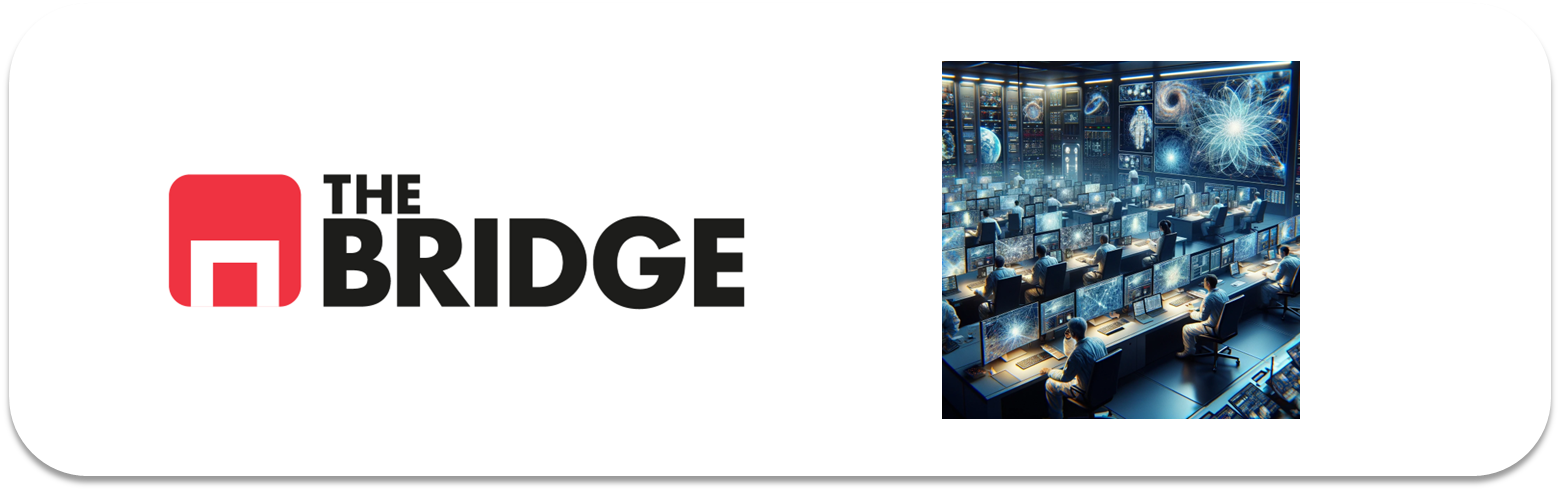

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [3]:
import bootcampviztools as bt
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
# filter warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split


### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



1. Crear dataset X,y leyendo imágenes

In [4]:
import os          # Permite interactuar con el sistema de archivos (leer carpetas y archivos)
import cv2         # Librería de OpenCV para leer y procesar imágenes
import numpy as np 

IMG_SIZE = 32      # Tamaño al que vamos a redimensionar todas las imágenes (32x32)

X = []             # Lista donde guardaremos las imágenes (features)
y = []             # Lista donde guardaremos las etiquetas o clases de cada imagen

folders = [        # Lista con las carpetas que contienen las imágenes de entrenamiento
    "data/github_train_0",
    "data/github_train_1",
    "data/github_train_2",
    "data/github_train_3"
]

for label, folder in enumerate(folders):   # Recorre cada carpeta asignando una etiqueta numérica (0,1,2,3)

    for file in os.listdir(folder):        # Recorre todos los archivos dentro de cada carpeta

        img_path = os.path.join(folder, file)  # Construye la ruta completa a la imagen

        img = cv2.imread(img_path)             # Lee la imagen desde disco y la carga como array
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # Redimensiona la imagen a 32x32 píxeles

        X.append(img)      # Añade la imagen procesada a la lista X
        y.append(label)    # Añade la etiqueta correspondiente a la lista y

X = np.array(X)            # Convierte la lista de imágenes en un array de numpy
y = np.array(y)            # Convierte la lista de etiquetas en un array de numpy

In [5]:
print(X.shape)
print(y.shape)

(4000, 32, 32, 3)
(4000,)


Se recorren las carpetas del dataset de entrenamiento leyendo cada imagen con OpenCV.  
Todas las imágenes se redimensionan a 32x32 píxeles para que tengan el mismo tamaño de entrada para la CNN.  
Las imágenes se almacenan en X y sus etiquetas correspondientes en y, generando así el dataset necesario para entrenar el modelo.  

In [6]:
print(np.unique(y)) # las clases que tiene 

[0 1 2 3]


In [7]:
from collections import Counter # Ver cuántas imágenes hay por clase

print(Counter(y))

Counter({np.int64(0): 1000, np.int64(1): 1000, np.int64(2): 1000, np.int64(3): 1000})


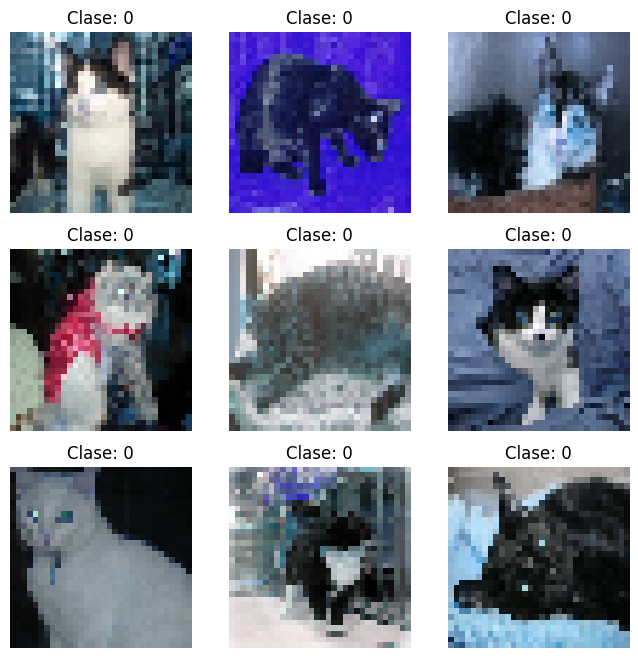

In [8]:
# Visualizar algunas imágenes
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

for i in range(9):
    
    plt.subplot(3,3,i+1)
    plt.imshow(X[i])
    plt.title(f"Clase: {y[i]}")
    plt.axis("off")

plt.show()

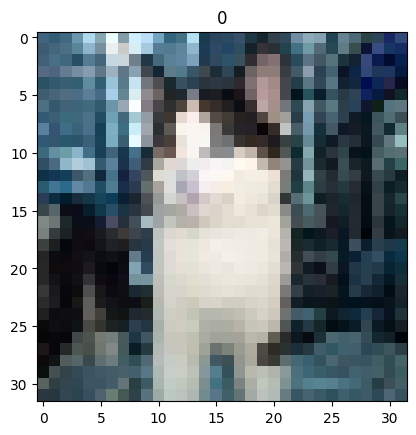

In [9]:
plt.imshow(X[0]) # Ver una imagen concreta
plt.title(y[0])
plt.show()

Se comprueba la dimensión del dataset generado y la distribución de clases.
El conjunto contiene 4000 imágenes redimensionadas a 32x32 píxeles distribuidas en 4 clases equilibradas.
Se visualizan algunas imágenes para verificar que se han cargado correctamente.

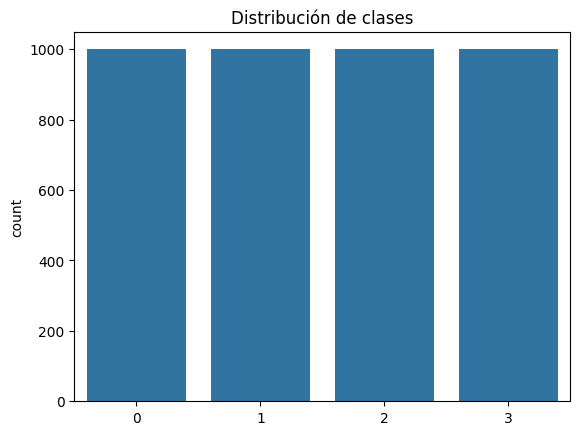

In [10]:
import seaborn as sns

sns.countplot(x=y)
plt.title("Distribución de clases")
plt.show()

Train / Test split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Normalizar imágenes

In [12]:
X_train = X_train / 255.0
X_val = X_val / 255.0

In [13]:
X_train[0]

array([[[0.02745098, 0.04705882, 0.09019608],
        [0.02352941, 0.01568627, 0.09019608],
        [0.01960784, 0.03137255, 0.0745098 ],
        ...,
        [0.01568627, 0.01568627, 0.03921569],
        [0.02352941, 0.01960784, 0.05882353],
        [0.02352941, 0.01960784, 0.03921569]],

       [[0.01568627, 0.03921569, 0.0745098 ],
        [0.00392157, 0.        , 0.01960784],
        [0.00392157, 0.        , 0.00784314],
        ...,
        [0.01176471, 0.01568627, 0.05490196],
        [0.01176471, 0.01960784, 0.05098039],
        [0.01568627, 0.01176471, 0.07058824]],

       [[0.02352941, 0.03921569, 0.0745098 ],
        [0.01960784, 0.00392157, 0.05098039],
        [0.00392157, 0.        , 0.00784314],
        ...,
        [0.01176471, 0.01568627, 0.05490196],
        [0.02745098, 0.03529412, 0.06666667],
        [0.01176471, 0.02352941, 0.04313725]],

       ...,

       [[0.37254902, 0.28235294, 0.25882353],
        [0.42352941, 0.3372549 , 0.29411765],
        [0.35294118, 0

SHUFFLE: SIEMPRE QUE ESTEN ORDENADOS, 2000 DE UN TIPO Y DEL OTRO MESCLARLOS

Construcción del modelo CNN

In [14]:
from tensorflow.keras import models, layers

model = models.Sequential([

    layers.RandomFlip("horizontal"),        # Voltea la imagen horizontalmente (simula nuevas imágenes)
    layers.RandomRotation(0.1),             # Rota ligeramente las imágenes para mejorar la generalización

    layers.Conv2D(32,(3,3),activation="relu",input_shape=(32,32,3)),  # Primera capa convolucional
    layers.MaxPooling2D(2,2),                                     # Reduce dimensionalidad

    layers.Conv2D(64,(3,3),activation="relu"),                     # Segunda capa convolucional
    layers.MaxPooling2D(2,2),                                      # Reduce nuevamente

    layers.Flatten(),                                              # Convierte los mapas de características en vector

    layers.Dense(128,activation="relu"),                           # Capa densa que aprende combinaciones de features
    layers.Dropout(0.3),                                           # Reduce overfitting apagando neuronas aleatoriamente

    layers.Dense(4,activation="softmax")                           # Capa de salida (4 clases)
])

Las capas Conv2D permiten extraer patrones visuales de las imágenes, como bordes, texturas y formas. En el primer bloque se utilizan 32 filtros para detectar características básicas, mientras que en el segundo se aumentan a 64 filtros para capturar patrones más complejos.

Las capas MaxPooling reducen la dimensionalidad de los mapas de características, permitiendo disminuir el número de parámetros y mejorar la generalización del modelo.

Posteriormente se utiliza una capa Flatten para transformar los mapas de características en un vector que pueda ser procesado por las capas densas.

Finalmente, una capa Dense de 128 neuronas actúa como clasificador intermedio y la capa final Dense con activación softmax genera las probabilidades de pertenencia a cada una de las cuatro clases del problema.

Compilar el modelo  

In [15]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Entrenamiento (con EarlyStopping)

In [16]:
# Crear el Callback EarlyStopping  
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    patience=5,
    restore_best_weights=True
)

# Entrenar el modelo 
history = model.fit(

    X_train,
    y_train,

    validation_data=(X_val,y_val),

    epochs=30,
    batch_size=32,

    callbacks=[early_stop]

)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.2719 - loss: 1.3896 - val_accuracy: 0.2500 - val_loss: 1.3848
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3031 - loss: 1.3602 - val_accuracy: 0.3462 - val_loss: 1.3242
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3350 - loss: 1.3268 - val_accuracy: 0.3100 - val_loss: 1.3403
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3291 - loss: 1.3119 - val_accuracy: 0.3438 - val_loss: 1.3053
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3503 - loss: 1.2894 - val_accuracy: 0.3438 - val_loss: 1.2756
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3625 - loss: 1.2760 - val_accuracy: 0.3250 - val_loss: 1.2804
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3703 - loss: 1.2607 - val_accuracy: 0.3237 - val_loss: 1.3062
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3831 - loss: 1.2564 - val_accu

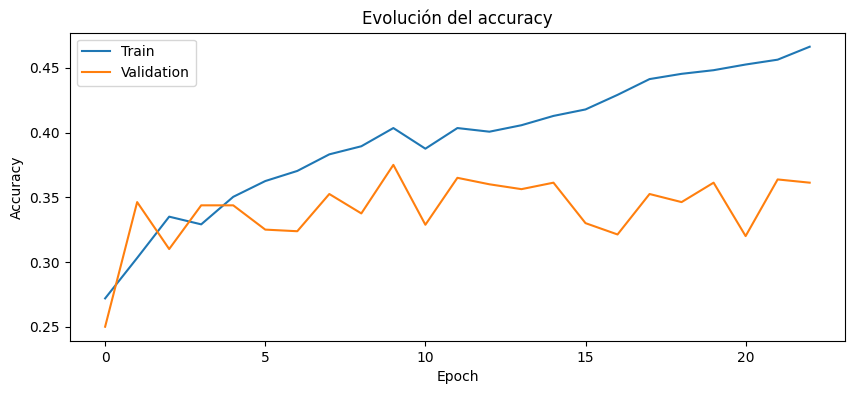

In [17]:
# historial de entrenamiento
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.plot(history.history["accuracy"])       # Accuracy en entrenamiento
plt.plot(history.history["val_accuracy"])   # Accuracy en validación

plt.title("Evolución del accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

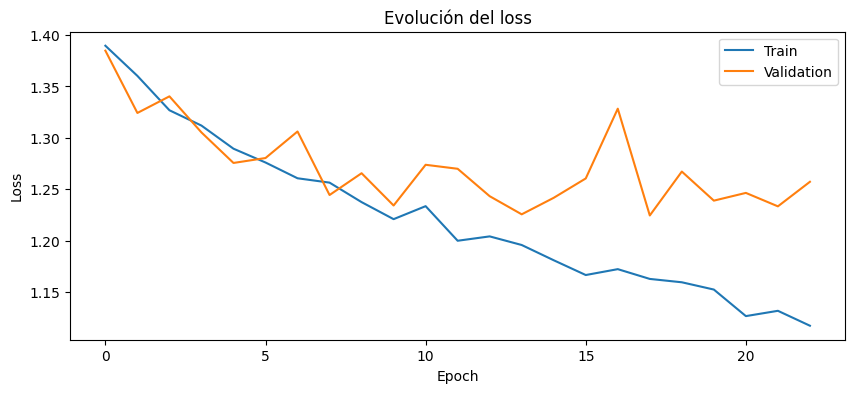

In [18]:
# mostrar el error
plt.figure(figsize=(10,4))

plt.plot(history.history["loss"])        # Error entrenamiento
plt.plot(history.history["val_loss"])    # Error validación

plt.title("Evolución del loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [19]:
# Evaluación del modelo
from sklearn.metrics import classification_report

y_pred = model.predict(X_val) # # El modelo devuelve probabilidades para cada clase
y_pred = np.argmax(y_pred, axis=1) # # Selecciona la clase con mayor probabilidad

print(classification_report(y_val, y_pred)) #  # Muestra precision, recall y f1-score

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
              precision    recall  f1-score   support

           0       0.34      0.56      0.43       200
           1       0.35      0.21      0.26       200
           2       0.37      0.38      0.37       200
           3       0.35      0.26      0.30       200

    accuracy                           0.35       800
   macro avg       0.35      0.35      0.34       800
weighted avg       0.35      0.35      0.34       800



El modelo obtiene una accuracy del 34% sobre el conjunto de validación.
Las métricas de precisión, recall y F1-score muestran valores relativamente equilibrados entre las distintas clases, aunque se observa que la clase 2 presenta un rendimiento inferior, lo que indica que resulta más difícil para el modelo distinguir este tipo de imágenes.

En general, el modelo consigue capturar ciertos patrones del dataset, aunque su capacidad de generalización todavía es limitada, lo cual es coherente con el reducido tamaño de las imágenes (32×32) y la complejidad del problema.

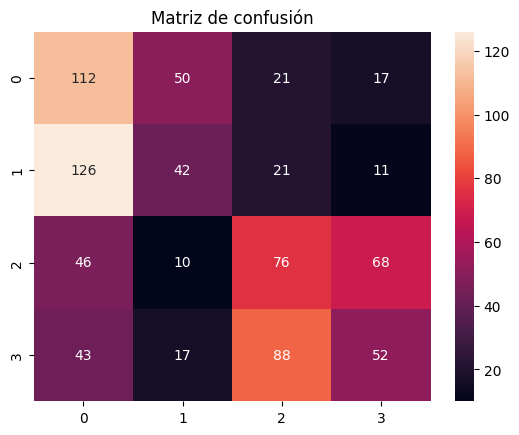

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, y_pred)  # Calcula la matriz de confusión

sns.heatmap(cm, annot=True, fmt="d")  # Visualiza la matriz
plt.title("Matriz de confusión")
plt.show()

Sin embargo, el modelo muestra confusiones relevantes entre las clases 0 y 1, así como entre las clases 2 y 3, lo que indica que estas categorías presentan características visuales similares que dificultan su diferenciación.

La clase 3 presenta el mejor comportamiento, con un mayor número de aciertos, mientras que la clase 2 resulta más difícil de clasificar correctamente.

Seleccionar el 10% de imágenes que el modelo clasifica mal pero con mayor confianza.

In [21]:
# Obtener probabilidades del modelo
y_pred_prob = model.predict(X_val)   # Probabilidades de cada clase

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


| Parte        | Significado                  |
| ------------ | ---------------------------- |
| **25/25**    | número de batches procesados |
| **0s**       | tiempo total                 |
| **3ms/step** | tiempo por batch             |


In [22]:
# Obtener la clase predicha
y_pred = np.argmax(y_pred_prob, axis=1)  # Clase con mayor probabilidad

In [23]:
# Obtener la confianza del modelo
confidence = np.max(y_pred_prob, axis=1)  # Probabilidad máxima

In [24]:
# Detectar errores
wrong = y_pred != y_val   # Detecta predicciones incorrectas

In [25]:
# Índices de errores
wrong_idx = np.where(wrong)[0]

In [26]:
# Ordenar errores por confianza
wrong_conf = confidence[wrong_idx]

sorted_idx = wrong_idx[np.argsort(-wrong_conf)]  # Mayor confianza primero

In [27]:
# Seleccionar el 10%
top_10_percent = int(len(sorted_idx) * 0.10)

hard_images = sorted_idx[:top_10_percent]

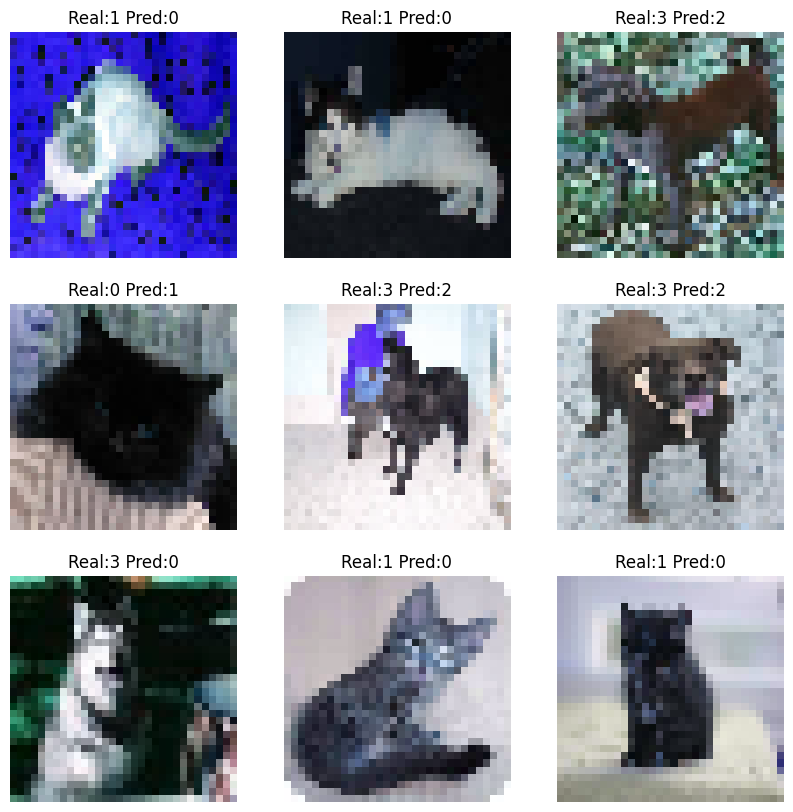

In [28]:
# Visualizar algunas imágenes difíciles
plt.figure(figsize=(10,10))

for i, idx in enumerate(hard_images[:9]):
    
    plt.subplot(3,3,i+1)
    plt.imshow(X_val[idx])
    plt.title(f"Real:{y_val[idx]} Pred:{y_pred[idx]}")
    plt.axis("off")

plt.show()

Finalmente se identifican las imágenes más difíciles para el modelo.  
Para ello se seleccionan las imágenes mal clasificadas con mayor nivel de confianza, es decir, aquellas en las que el modelo se equivoca pero muestra una alta probabilidad en su predicción incorrecta.  

Estas imágenes representan casos especialmente ambiguos y constituyen buenos candidatos para sistemas CAPTCHA, ya que también podrían resultar difíciles para sistemas automatizados de clasificación de imágenes.  
Puedes mencionar que en tu matriz de confusión se observó que el modelo confunde principalmente:  
clase 0 ↔ clase 1  
clase 2 ↔ clase 3  
Por lo tanto, las imágenes difíciles aparecerán principalmente entre esas clases.